# EXERCÍCIOS PORPOSTOS SOBRE VENDAS DE ECOMMERCE

## Preparação

In [1]:
# importação das bibliotecas necessárias
import pandas as pd
import sqlite3


In [2]:
#ler o arquivo
df = pd.read_csv('vendas_desafio.csv')

# conferir a integridade dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_venda        10000 non-null  int64  
 1   data_venda      10000 non-null  str    
 2   cliente         10000 non-null  str    
 3   produto         10000 non-null  str    
 4   categoria       10000 non-null  str    
 5   quantidade      10000 non-null  int64  
 6   preco_unitario  10000 non-null  float64
 7   vendedor        10000 non-null  str    
 8   cidade          10000 non-null  str    
 9   estado          10000 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 781.4 KB


In [ ]:
# construir o banco de dados

# criar conexão sqlite3
conn = sqlite3.connect('analise_vendas.db')

# criar o banco de dados a partir do csv
df.to_sql(
    'vendas', # nome da tabela
    con = conn, # conexão criada acima
    if_exists='replace', # se já existir a tabela, apaga e cria outra
    index=False # não carregar os índices do dataframe na tabela
)

# não esquecer de fechar a conexão
conn.close()

A partir desse ponto já foi criado o banco de dados .db com os dados do .csv original. Assim, já é possível usar comando SQL para iniciar as atividades propostas.

## Atividades em SQL

### 1. Qual o faturamento total por produto?

In [5]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        produto,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY produto
    ORDER BY SUM(quantidade * preco_unitario) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta

,produto,faturamento_total
0,Notebook,"R$ 8,290,852.39"
1,Mesa,"R$ 3,092,939.21"
2,Monitor,"R$ 2,364,641.86"
3,Cadeira,"R$ 1,629,832.30"
4,Fone,"R$ 495,633.09"
5,Mochila,"R$ 460,376.91"
6,Teclado,"R$ 384,771.59"
7,Livro Python,"R$ 296,630.22"
8,Livro SQL,"R$ 247,460.70"
9,Mouse,"R$ 205,764.16"


_nota:_ A concatenação de 'R$' e o uso de _format_ são apenas para facilitar a visualização do resultado. O número em si dentro do banco de dados continua como um float.

### 2. Qual o faturamento total por categoria?

In [6]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        categoria,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY categoria
    ORDER BY SUM(quantidade * preco_unitario) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta

,categoria,faturamento_total
0,Eletrônicos,"R$ 11,741,663.09"
1,Móveis,"R$ 4,722,771.51"
2,Livros,"R$ 544,090.92"
3,Acessórios,"R$ 460,376.91"


### 3. Qual o ticket médio por cliente?

In [ ]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        cliente,
        'R$ ' || format('%,.2f', (SUM(quantidade * preco_unitario) / COUNT(cliente))) AS ticket_medio
    FROM vendas 
    GROUP BY cliente
    ORDER BY (SUM(quantidade * preco_unitario) / COUNT(cliente)) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta

,cliente,ticket_medio
0,Mathias,"R$ 2,991.26"
1,Isabelly,"R$ 2,969.92"
2,Thiago,"R$ 2,828.27"
3,Danilo,"R$ 2,814.02"
4,Nicole,"R$ 2,767.90"
...,...,...
277,Maria Liz,R$ 756.46
278,Liam,R$ 730.25
279,Gabriel,R$ 686.12
280,Mariane,R$ 653.83


### 4. Qual o faturamento total por vendedor?

In [8]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        vendedor,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY vendedor
    ORDER BY SUM(quantidade * preco_unitario) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta

,vendedor,faturamento_total
0,Ana,"R$ 3,544,588.45"
1,Bruno,"R$ 3,501,930.96"
2,Eduardo,"R$ 3,477,302.18"
3,Carlos,"R$ 3,476,724.22"
4,Daniela,"R$ 3,468,356.62"


### 5. Qual o faturamento por mês?

In [21]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        strftime('%m', data_venda) AS mes,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY mes
    ORDER BY mes
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta

,mes,faturamento_total
0,01,"R$ 1,332,505.24"
1,02,"R$ 1,414,699.44"
2,03,"R$ 1,561,420.22"
3,04,"R$ 1,571,459.42"
4,05,"R$ 1,537,043.09"
5,06,"R$ 1,346,568.09"
6,07,"R$ 1,528,937.90"
7,08,"R$ 1,531,974.02"
8,09,"R$ 1,560,269.23"
9,10,"R$ 1,423,821.79"


### 6. Quais são os 5 produtos mais vendidos?

In [31]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        produto,
        SUM(quantidade) AS 'Quantidade vendida'
    FROM vendas 
    GROUP BY produto
    ORDER BY SUM(quantidade) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
df_resposta.head()

,produto,Quantidade vendida
0,Monitor,2613
1,Mouse,2581
2,Mesa,2581
3,Teclado,2566
4,Mochila,2557


### 7. Qual cidade possui maior faturamento?

In [ ]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        cidade,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY cidade
    ORDER BY SUM(quantidade * preco_unitario) DESC
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
print(f"A cidade que apresentou maior faturamento foi {df_resposta['cidade'][0]} com um total de {df_resposta['faturamento_total'][0]}")

A cidade que apresentou maior faturamento foi Curitiba com um total de R$ 3,636,297.53


### 8. Qual cliente comprou mais em valor?

In [36]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# a query a ser executada
query = """ 
    SELECT
        cliente,
        'R$ ' || format('%,.2f', SUM(quantidade * preco_unitario)) AS faturamento_total
    FROM vendas 
    GROUP BY cliente
    ORDER BY SUM(quantidade * preco_unitario) DESC
    LIMIT 1
"""

# execução da query criada acima
df_resposta = pd.read_sql_query(query, con=conn)

# não esquecer de fechar a conexão
conn.close()

# exibir a resposta
print(f"O cliente que mais comprou, em valor, foi {df_resposta['cliente'][0]} com um total de {df_resposta['faturamento_total'][0]}")

O cliente que mais comprou, em valor, foi Mathias com um total de R$ 122,641.69


### Extra: Criar uma tabela resumo_vendas

In [ ]:
# abre a conexão com o banco de dados
conn = sqlite3.connect("analise_vendas.db")

# limpar a tabela se já existir
query =""" 
    DROP TABLE IF EXISTS resumo_vendas;

    CREATE TABLE resumo_vendas AS
        SELECT
            produto,
            categoria,
            SUM (quantidade) AS quantidade_total,
            SUM(quantidade * preco_unitario) AS faturamento_total
        FROM vendas 
        GROUP BY produto
"""

# execução da query criada acima
conn.executescript(query)

# não esquecer de fechar a conexão
conn.close()

,produto,categoria,quantidade_total,faturamento_total
0,Cadeira,Móveis,2319,1629832.30
1,Fone,Eletrônicos,2469,495633.09
2,Livro Python,Livros,2470,296630.22
3,Livro SQL,Livros,2474,247460.70
4,Mesa,Móveis,2581,3092939.21
5,Mochila,Acessórios,2557,460376.91
6,Monitor,Eletrônicos,2613,2364641.86
7,Mouse,Eletrônicos,2581,205764.16
8,Notebook,Eletrônicos,2364,8290852.39
9,Teclado,Eletrônicos,2566,384771.59


## Atividades em Python

### Ler o arquivo .csv

In [2]:
df = pd.read_csv('vendas_desafio.csv')

### Criar coluna faturamento (quantidade * preço unitário)

In [5]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2024-11-19,Cauã,Teclado,Eletrônicos,1,141.84,Carlos,Belo Horizonte,RJ,141.84
9996,9997,2024-01-22,Luara,Livro Python,Livros,1,114.31,Carlos,Belo Horizonte,SP,114.31
9997,9998,2024-07-20,Vitória,Livro Python,Livros,2,119.01,Eduardo,Porto Alegre,RJ,238.02
9998,9999,2024-07-15,Ravi Lucca,Mochila,Acessórios,4,183.76,Bruno,Curitiba,PR,735.04


### Agrupar faturamento por produto

In [7]:
novo_df = df.groupby('produto')['faturamento'].sum().reset_index()
novo_df

,produto,faturamento
0,Cadeira,1629832.30
1,Fone,495633.09
2,Livro Python,296630.22
3,Livro SQL,247460.70
4,Mesa,3092939.21
5,Mochila,460376.91
6,Monitor,2364641.86
7,Mouse,205764.16
8,Notebook,8290852.39
9,Teclado,384771.59


### Agrupar faturamento por cliente

In [9]:
novo_df = df.groupby('cliente')['faturamento'].sum().reset_index()
novo_df

,cliente,faturamento
0,Agatha,72802.44
1,Alana,46255.65
2,Alexandre,65418.73
3,Alexia,56553.65
4,Alice,100859.35
...,...,...
277,Yasmin,34916.61
278,Yuri,72390.77
279,Zoe,82937.55
280,Ágatha,73101.56


### Agrupar faturamento por categoria

In [12]:
novo_df = df.groupby('categoria')['faturamento'].sum().reset_index()
novo_df

,categoria,faturamento
0,Acessórios,460376.91
1,Eletrônicos,11741663.09
2,Livros,544090.92
3,Móveis,4722771.51


### Criar gráfico de faturamento por categoria

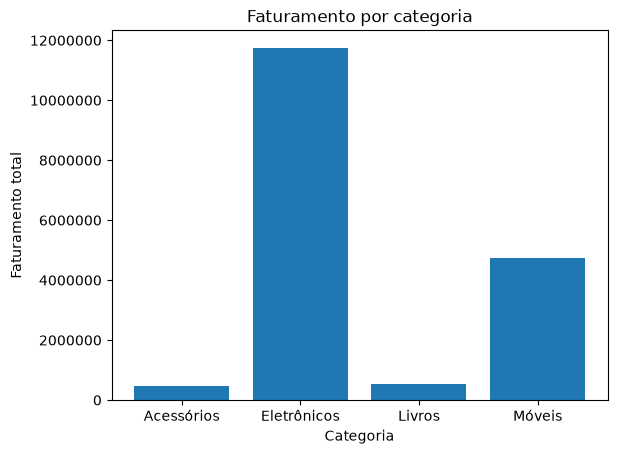

In [22]:
# importar biblioteca necessária
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.bar(
    novo_df['categoria'],
    novo_df['faturamento'],
)

ax.set_title('Faturamento por categoria')
ax.set_xlabel('Categoria')
ax.set_ylabel('Faturamento total')
ax.ticklabel_format(style='plain', axis='y')

plt.show()


### Exportar arquivo resumo_vendas.csv

In [27]:
# salvar a tabela do banco de dados em um dataframe

# abrir conexão
conn = sqlite3.connect('analise_vendas.db')

query = """ 
    SELECT * FROM resumo_vendas
"""

resumo = pd.read_sql_query(query, con=conn)

#não esqueça de fechar a conexão
conn.close()

# salvar o df resultado em um csv
resumo.to_csv('resumo_vendas.csv',
              index = False,
              sep=';', # evita problemas com a virgula de casas decimais
              encoding= 'utf-8' # evita problemas com caracteres especiais
              )